# **Logistic Regression**

“Logistic regression is a classification algorithm used to predict the probability that an example belongs to a particular class.”

**Important Points**



1.   Ye classification algorithm hai (regression naam confusing hai 👀).


2. Ye output ko probability ke form mein deta hai.

3. Hypothesis function hoti hai:





# **Why Not Linear Regression?**

Linear Regression gives output using this equation:

y=w1​x1​+w2​x2​+b

The problem is:

* The output can be less than 0

* he output can be greater than 1

* But in classification problems, we usually want to predict probability.




And probability must always lie between 0 and 1.

For example:

* 0 → 0% chance

* 1 → 100% chance

* 0.8 → 80% chance

If Linear Regression gives an output like:

1.5

-0.3

These values are not valid probabilities.

So Linear Regression is not suitable for classification problems.

That is why we use Logistic Regression, which applies the sigmoid function to ensure the output is always between 0 and 1.

# **Enter Sigmoid Function (Heart of Logistic Regression)**

**Problem: Linear Equation Gives Unbounded Output**

Solution: Sigmoid Function

σ(z)=1/1+e**−z

	​


Sigmoid converts any value (−∞ to +∞) into a number between 0 and 1.

If
𝑧
z is very negative → output ≈ 0

If
𝑧
z is very positive → output ≈ 1

If
𝑧
=
0
z=0 → output = 0.5

So sigmoid solves the unbounded output problem and makes logistic regression suitable for classification.


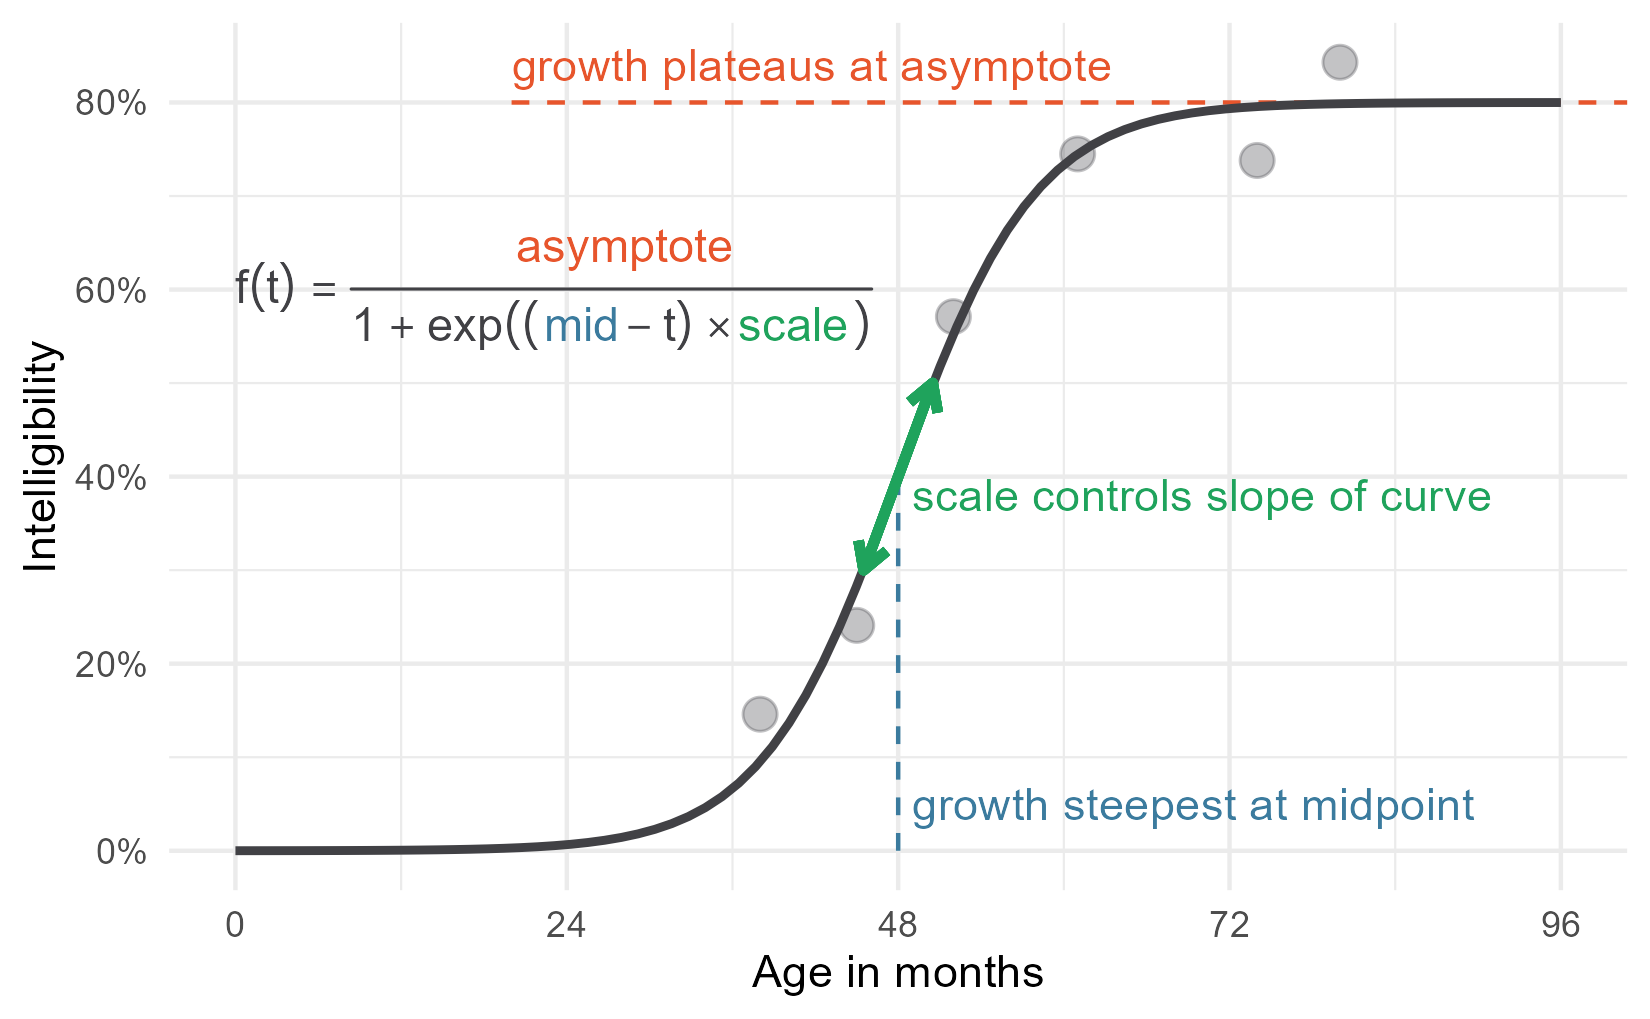

# Final Prediction

Final Prediction (Very Short)

* Sigmoid gives a probability (between 0 and 1).

* We use a threshold (0.5) to decide the class.

Rule:

* If probability ≥ 0.5 → Class 1

* If probability < 0.5 → Class 0

# **Cost Function**

Linear regression MSE use karta hai.
But logistic regression use karta hai: **`Log Loss / Binary Cross Entropy`**

Kyuki sigmoid non-linear hai, MSE convex nahi hota.

Loss formula:

−
(
𝑦
log
⁡
(
𝑝
)
+
(
1
−
𝑦
)
log
⁡
(
1
−
𝑝
)
)

Yeh model ko punish karta hai agar galat confident prediction kare.


# **Decision** **Boundary**
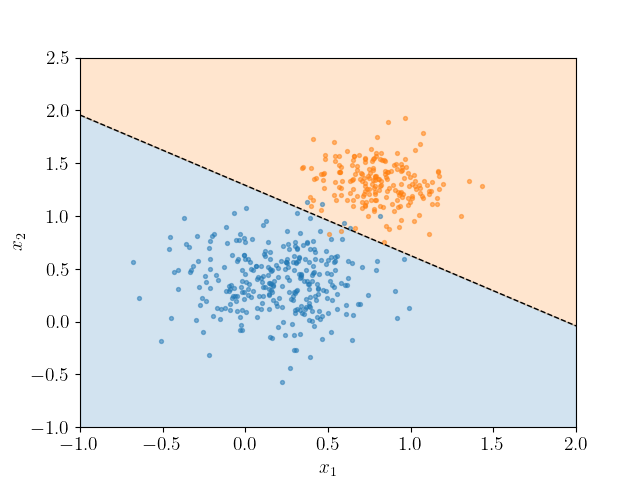

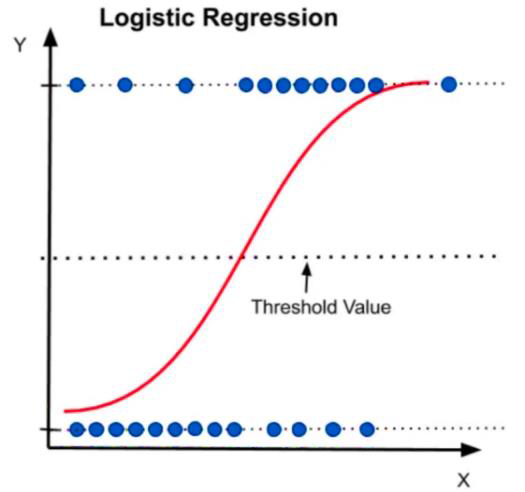

# **Hands on Implementation using sklearn**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.linear_model import LogisticRegression

In [ ]:
df=pd.read_csv("/content/Social_Network_Ads (1).csv")
df.sample ()

,User ID,Gender,Age,EstimatedSalary,Purchased
49,15793813,Female,31,89000,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB


In [ ]:
df = pd.get_dummies(df, columns=['Gender'])

In [ ]:
df.sample()

,User ID,Age,EstimatedSalary,Purchased,Gender_Female,Gender_Male
221,15663161,35,91000,1,False,True


In [ ]:
df.drop(['User ID','Gender_Male'],axis=1,inplace=True)

In [ ]:
df

,Age,EstimatedSalary,Purchased,Gender_Female
0,19,19000,0,False
1,35,20000,0,False
2,26,43000,0,True
3,27,57000,0,True
4,19,76000,0,False
...,...,...,...,...
395,46,41000,1,True
396,51,23000,1,False
397,50,20000,1,True
398,36,33000,0,False


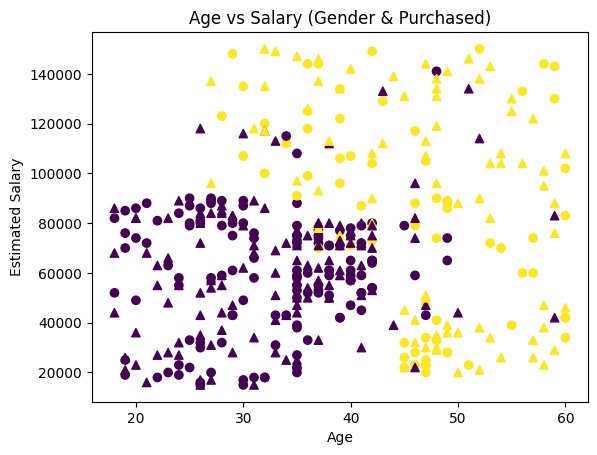

In [ ]:
import matplotlib.pyplot as plt
male = df[df['Gender_Female'] == False]
female = df[df['Gender_Female'] == True]
plt.figure()
plt.scatter(
    male['Age'],
    male['EstimatedSalary'],
    c=male['Purchased'],
    marker='o'
)


plt.scatter(
    female['Age'],
    female['EstimatedSalary'],
    c=female['Purchased'],
    marker='^'
)

plt.xlabel("Age")
plt.ylabel("Estimated Salary")
plt.title("Age vs Salary (Gender & Purchased)")

plt.show()

In [ ]:
model=LogisticRegression()
df.columns


Index(['Age', 'EstimatedSalary', 'Purchased', 'Gender_Female'], dtype='object')

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(df[['Age', 'EstimatedSalary','Gender_Female']],df[['Purchased']],test_size=0.2,random_state=42)

In [ ]:
X_train.shape

(320, 3)

In [ ]:
model.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [ ]:
model.score(X_test,y_test)

0.825

# Important Points

 `if model prediction is 1 so be careful chance your model is overfitted `

Solution : check your data is not too samll

2.  use cross validation approch

3.  tuning hypermeters


In [ ]:
scores = cross_val_score(model, df[['Age', 'EstimatedSalary','Gender_Female']], df[['Purchased']], cv=5)

print("Cross Validation Scores:", scores)
print("Average Accuracy:", scores.mean())

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression


Cross Validation Scores: [0.7    0.9625 0.9375 0.8125 0.7   ]
Average Accuracy: 0.8225


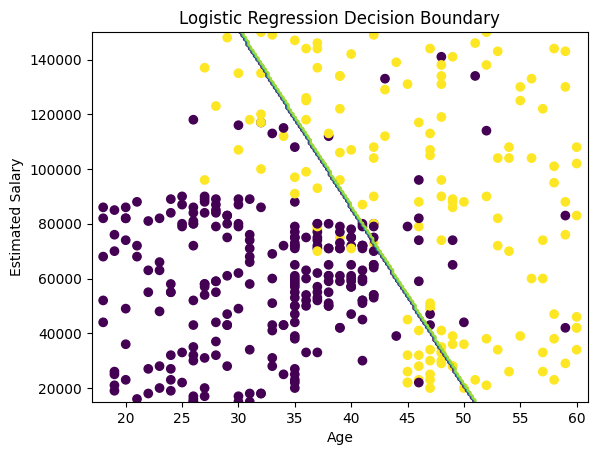

In [ ]:
# this part of code i get from chatgpt



import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# Features and target
X = df[['Age', 'EstimatedSalary']].values
y = df['Purchased'].values

# Train model
model = LogisticRegression()
model.fit(X, y)

# Scatter original data
plt.scatter(X[:, 0], X[:, 1], c=y)

# Create mesh grid
x_min, x_max = X[:, 0].min()-1, X[:, 0].max()+1
y_min, y_max = X[:, 1].min()-1, X[:, 1].max()+1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

# Predict for every point in grid
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot decision boundary
plt.contour(xx, yy, Z)

plt.xlabel("Age")
plt.ylabel("Estimated Salary")
plt.title("Logistic Regression Decision Boundary")

plt.show()

# Reference Book
Hands on Machine learing
https://www.amazon.com/Hands-Machine-Learning-Scikit-Learn-TensorFlow/dp/1098125975

# Reference youtube video
https://www.youtube.com/watch?v=XNXzVfItWGY&list=PLKnIA16_Rmvb-ZTsM1QS-tlwmlkeGSnru